In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

## Training our model with counting 

In [3]:
with open("../data/names.txt", 'r') as f:
    words = f.read().splitlines()
words = [w.strip().lower() for w in words if w.strip() != ""]


In [4]:
# array of alhpabetics
start = ord('a'); end = start + 26
chars = [chr(i) for i in range(start, end)]

#encoding
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

#decoding
itos = {i:s for s, i in stoi.items()}


print(stoi)
print(itos)


{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
N = torch.zeros((27, 27), dtype=torch.int32)

### Creating a count matrix N of biagrams
N[stoi(chr1),stoi(char2)] -> number of bigram (ch1, ch2) in the training set (words)

In [6]:
for w in words:
    chs = '.' + w + '.'
    for ch1 ,ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        i, j = stoi[ch1], stoi[ch2]
        N[i, j] +=1

## Visualizing N

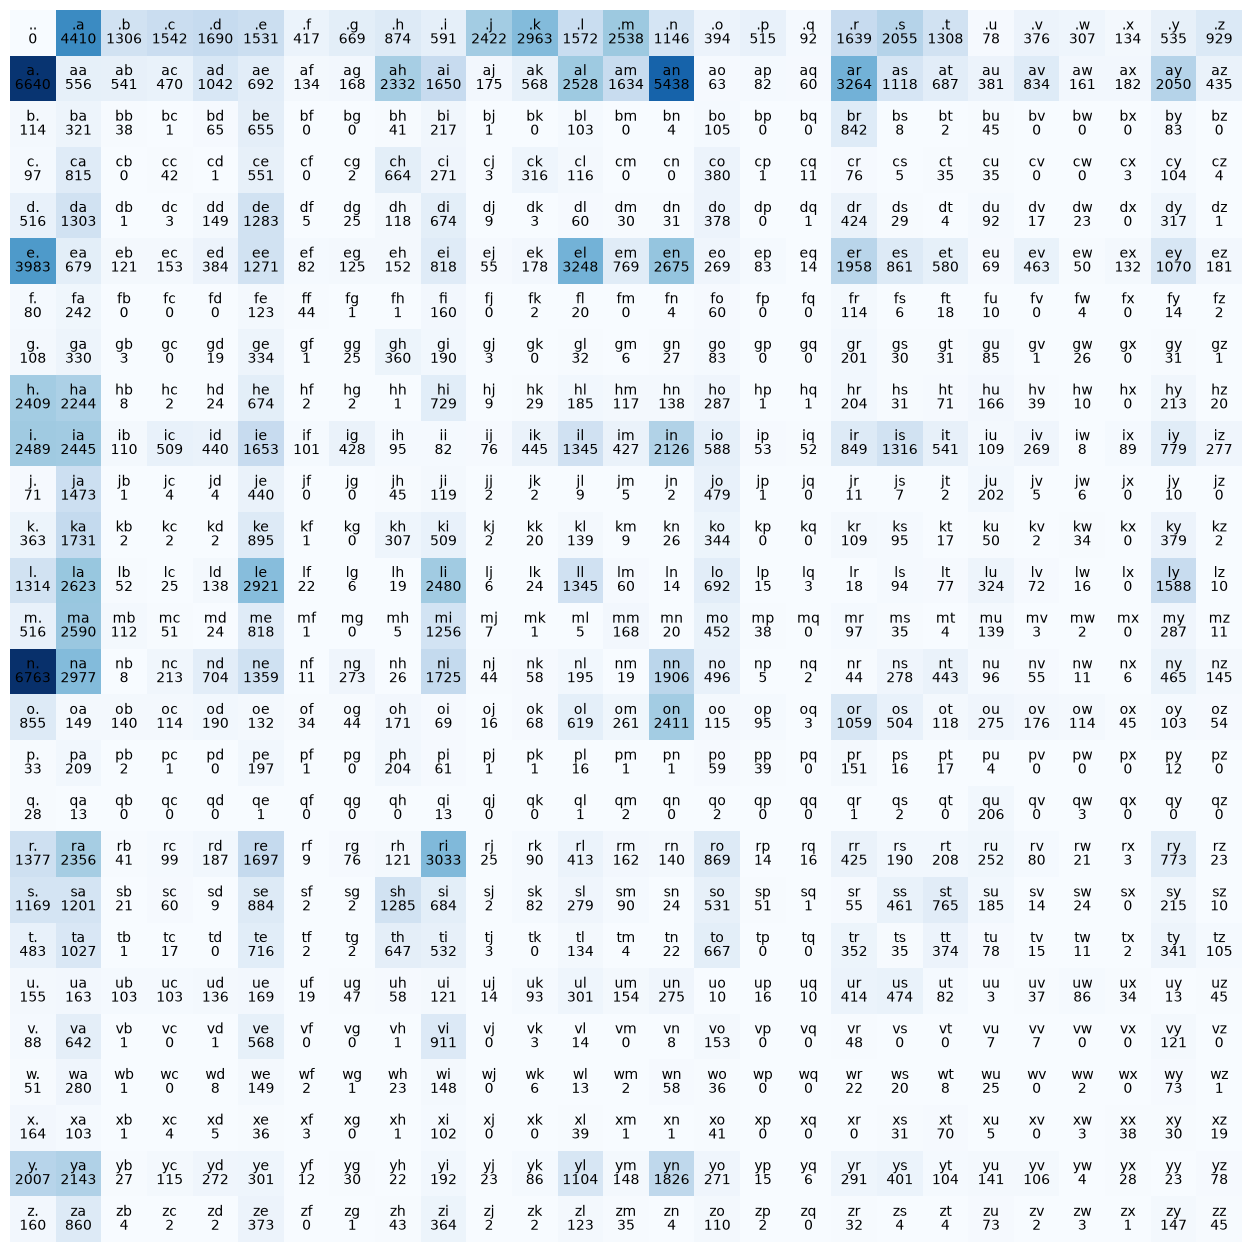

In [7]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom")
        plt.text(j, i, N[i, j].item(), ha="center", va="top")
        
plt.axis("off")
plt.show()



## Creating the probability Matrix
p[i, j] -> the probability of the ch2 following ch1. (ch1 = itos[i], ch2 = itos[j])

In [8]:

P = (N + 1).float() # we add 1 for smothing
P = P / P.sum(dim=1, keepdim=True)



## Testing our model
predicting 20 words

In [9]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    word = ''
    ix = 0 # predict the next character after '.' (beginning of the word)
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        word += itos[ix]
        
        if ix == 0:
            break # break when the predictable character is '.' (end of the word)
        
    print(word)

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [10]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        prob = P[ix1, ix2]
        print(f"{ch1}{ch2} : {prob:.4f}")

.e : 0.0478
em : 0.0377
mm : 0.0253
ma : 0.3885
a. : 0.1958
.o : 0.0123
ol : 0.0779
li : 0.1774
iv : 0.0152
vi : 0.3508
ia : 0.1380
a. : 0.1958
.a : 0.1376
av : 0.0246
va : 0.2473
a. : 0.1958


## Measure the quality of our model
L = (-1/n_samples)*(log(likelihood))

In [11]:
len(words)

32033

In [12]:
#likelihood
llh = 1
n_samples = 0 # number of bigrams

for w in words:
    chstr = '.' + w + '.'
    for ch1, ch2 in zip(chstr, chstr[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        n_samples += 1
        p = P[ix1, ix2]

        llh += torch.log(p)


#log likelihood
print(f"the log likelihood is {llh}")

# the loss
L = (-1 / n_samples) * (llh)
print(f"the loss is : {L}")  # our goal is to : minimize the loss <=> maximize the likelihood

the log likelihood is -559950.5625
the loss is : 2.4543519020080566


In [13]:
# Check the probability of 'm' (index 13) starting a word (row 0)
print(f"Probability of 'm' starting a word: {P[0, 13].item():.4f}")

Probability of 'm' starting a word: 0.0792


# Training our Model using neural network

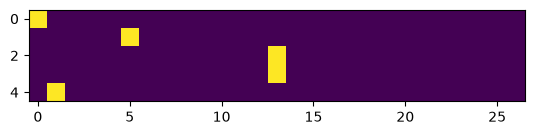

In [14]:
# training set 
xs , ys = [], []

for w in words[:1]:
    chstr = '.' + w + '.'
    for ch1, ch2 in zip(chstr, chstr[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

xenc = F.one_hot(xs, 27).float()

plt.imshow(xenc)

In [15]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [16]:
logits = xenc @ W # (n_samples, 27)
counts = logits.exp()

#matrix of probabilities : p[i] is the probability of each character after the i-th input
P = counts / counts.sum(dim=1, keepdim=True)
P.sum(1)


tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)

In [17]:
Ls = torch.zeros(5)
for i in range(5):
    x, y = xs[i].item(), ys[i].item() # input and label character index
    print(f"this is the {i + 1} exemple : ({itos[x]}, {itos[y]}) of indexes ({x}, {y})")

    p = P[i, y]
    print(f"the probability of the correct label is : {p}")

    L = - torch.log(p)
    print(f"the loss is : {L}")
    Ls[i] = L

print("\n")
print("=" * 25 + "The end" + "=" * 25)
print("\n")

print(f"The vector of losses : {Ls}")
print(f"The average loss is : {Ls.mean().item()}")

this is the 1 exemple : (., e) of indexes (0, 5)
the probability of the correct label is : 0.012286250479519367
the loss is : 4.3992743492126465
this is the 2 exemple : (e, m) of indexes (5, 13)
the probability of the correct label is : 0.018050704151391983
the loss is : 4.014570713043213
this is the 3 exemple : (m, m) of indexes (13, 13)
the probability of the correct label is : 0.026691533625125885
the loss is : 3.623408794403076
this is the 4 exemple : (m, a) of indexes (13, 1)
the probability of the correct label is : 0.07367684692144394
the loss is : 2.6080667972564697
this is the 5 exemple : (a, .) of indexes (1, 0)
the probability of the correct label is : 0.01497753243893385
the loss is : 4.2012038230896


=========================The end=========================


The vector of losses : tensor([4.3993, 4.0146, 3.6234, 2.6081, 4.2012], grad_fn=<CopySlices>)
The average loss is : 3.7693049907684326


## -------- OPTIMIZATION ----------

In [18]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [24]:
# training set 
xs , ys = [], []

for w in words:
    chstr = '.' + w + '.'
    for ch1, ch2 in zip(chstr, chstr[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

n_samples = xs.nelement()
print(f"the number of biagrams is : {n_samples}")

xenc = F.one_hot(xs, 27).float()
xenc[:3]

the number of biagrams is : 228146


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
for i in range(1000):
    # forward pass
    logits = xenc @ W
    counts = logits.exp()

    prob = counts / counts.sum(dim=1, keepdim=True)
    loss = -P[torch.arange(n_samples), ys].log().mean() 

    # backward pass
    W.grad = None
    loss.backward()

    # update 
    step = 10
    W.data -= step * W.grad

   

In [63]:
logits = xenc @ W
counts = logits.exp()

prob = counts / counts.sum(dim=1, keepdim=True)
loss = -prob[torch.arange(n_samples), ys].log().mean()
prob.shape

torch.Size([228146, 27])

In [62]:
with torch.no_grad():
    # An identity matrix represents all 27 individual tokens one-hot encoded
    token_enc = F.one_hot(torch.arange(27), num_classes=27).float()
    logits_nn = token_enc @ W
    counts_nn = logits_nn.exp()
    P_nn = counts_nn / counts_nn.sum(dim=1, keepdim=True)

g = torch.Generator().manual_seed(2147483647)


for i in range(20):
    word = ''
    ix = 0 # predict the next character after '.' (beginning of the word)
    while True:
        p = P_nn[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        word += itos[ix]
        
        if ix == 0:
            break # break when the predictable character is '.' (end of the word)
        
    print(word)

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)